# Backpropagation Lab





In [8]:
from sklearn.neural_network import MLPClassifier, MLPRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

## 1 Avoiding Overfit: Early Stopping and Loss Regularization

### 1.1 (10%) No overfit avoidance
Train the sklearn [MLP classifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier) on the [Iris Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/iris.arff).  Use 3 output nodes (1 per class). Expanding the one output variable into 3 is called one-hot encoding or dummy variable encoding. There are lots of ways to implement this including the Pandas get_dummies method. This experiment is set up to run a little longer to better see the effects of overfit.  Be patient as there are lots of hidden nodes and a high max iterations setting.

Use default parameters except for the following:
- hidden_layer_sizes = [64] - One hidden layer with 64 hidden nodes
- activation = 'logistic'
- solver = 'sgd'
- alpha = 0
- batch_size = 1
- learning_rate_init = 0.01
- shuffle = True
- momentum = 0
- n_iter_no_change = 50
- max_iterations = 10000

Use a random 80/20 split of the data.  Run it a few times with different random training/test splits and give average values for
- Number of iterations until convergence
- Training set accuracy
- Test set accuracy
For one run observe the softmax probabilities on the test set using clf.predict_proba

In [ ]:
#Iris with no regularization

# Load data set
train_data, _ = arff.loadarff("data/iris.arff")
iris_df = pd.DataFrame(train_data)

# Quick EDA
print("EDA:")
print("First 5 rows of Iris data set:")
display(iris_df.head())

print("\nIris Class Distributions: ")
display(iris_df["class"].value_counts().sort_index())

# X and y
X = iris_df.drop(["class"], axis = 1)
y = iris_df["class"]

# One-hot encode the categorical class column
y = pd.get_dummies(y)

# Set up the data table to be added to:
train_accuracies = []
test_accuracies = []
n_iters = []

# Do 5 random splits and train the model:
for i in range(5):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = 0.2
    )
    # train and fit the model
    mlp_classifier = MLPClassifier(
        hidden_layer_sizes = [64], 
        activation = "logistic",
        solver = "sgd",
        alpha = 0,
        batch_size = 1,
        learning_rate_init = 0.01,
        shuffle = True,
        momentum = 0,
        n_iter_no_change = 50,
        max_iter = 10000
    )
    mlp_classifier.fit(X_train, y_train)

    # predicitions:
    train_pred = mlp_classifier.predict(X_train)
    test_pred = mlp_classifier.predict(X_test)

    # get accuracies and num iters:
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # num iters
    iters = mlp_classifier.n_iter_

    # add to lists
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    n_iters.append(iters)

    # for first run, print softmax probs
    if i == 0:
        print("\nSoft Max probs on test set:")
        print(mlp_classifier.predict_proba(X_test))

# turn into dictionaries, data frame, display
accuracies = {"Model": [i for i in range(1, 6)], 
              "Train Accuracy": train_accuracies, 
              "Test Accuracy": test_accuracies, 
              "Num. Iters": n_iters}
accuracies = pd.DataFrame(accuracies)
display(accuracies)

# Get averages:
avg_train = sum(train_accuracies) / len(train_accuracies)
avg_test = sum(test_accuracies) / len(test_accuracies)
avg_iter = sum(n_iters) / len(n_iters)

# average dictionary, data frame, display:
averages = {"Metric": ["Train Accuracy:", "Test Accuracy:", "Num. Iters:"], 
            "Average:" : [avg_train, avg_test, avg_iter]}
averages = pd.DataFrame(averages)
display(averages)

EDA:
First 5 rows of Iris data set:


,sepallength,sepalwidth,petallength,petalwidth,class
0,5.1,3.5,1.4,0.2,b'Iris-setosa'
1,4.9,3.0,1.4,0.2,b'Iris-setosa'
2,4.7,3.2,1.3,0.2,b'Iris-setosa'
3,4.6,3.1,1.5,0.2,b'Iris-setosa'
4,5.0,3.6,1.4,0.2,b'Iris-setosa'



Iris Class Distributions: 


class
b'Iris-setosa'        50
b'Iris-versicolor'    50
b'Iris-virginica'     50
Name: count, dtype: int64


Soft Max probs on test set:
[[9.17149945e-06 1.75145113e-01 8.93096292e-01]
 [1.14018291e-06 3.80237065e-03 9.98833926e-01]
 [9.99626920e-01 2.05649771e-03 5.61821830e-12]
 [2.18795758e-06 1.46308978e-02 9.94863432e-01]
 [2.97498327e-06 1.82719099e-02 9.91483632e-01]
 [2.67493733e-03 9.98715244e-01 7.42144060e-05]
 [4.49359300e-04 9.92132060e-01 2.17398895e-03]
 [5.99364882e-04 9.93212064e-01 1.34519020e-03]
 [6.49698800e-06 9.18790097e-02 9.48973837e-01]
 [2.57628627e-04 9.81344348e-01 7.18994417e-03]
 [9.99241337e-01 3.21124921e-03 1.45292190e-11]
 [5.90277853e-05 8.13555403e-01 1.43276978e-01]
 [1.28243388e-06 5.29756036e-03 9.98410196e-01]
 [3.37362147e-04 9.78603984e-01 5.08429437e-03]
 [7.83848798e-04 9.92555072e-01 9.52467067e-04]
 [2.32525960e-06 1.52176680e-02 9.94187981e-01]
 [9.98003125e-01 8.02083144e-03 4.64768476e-11]
 [1.51242491e-04 9.41729449e-01 2.50400259e-02]
 [7.71572756e-06 9.02019211e-02 9.34957347e-01]
 [2.00438927e-03 9.98683027e-01 1.16010795e-04]
 [3.3907836

,Model,Train Accuracy,Test Accuracy,Num. Iters
0,1,0.983333,0.966667,366
1,2,0.966667,0.966667,363
2,3,0.983333,0.966667,321
3,4,0.983333,0.966667,264
4,5,0.958333,1.000000,252


,Metric,Average:
0,Train Accuracy:,0.975000
1,Test Accuracy:,0.973333
2,Num. Iters:,313.200000


#### Discussion
In the markdown cell below, write about your experience training the MLP classifier. Things to cover in your discussion: How long did it take? What was your accuracy on the training set? What was your accuracy on the testing set? Do you see any evidence of overfitting? If so, what could be done to reduce the effects of overfitting?

Quick Process Overview:
    I did a quick EDA, as I normally do, followed by one-hot encoding the class feature to binary categorical values. I then did a for loop to split my data into 5 different 80/20 splits, intialized and fit my classifier, and crunched the numbers for each of the models. I also did a little formatting towards the bottom to get it to output in a nice table.

It didn't take too long - just about a minute and a half to run everything. I was honestly expecting it to run longer based on the description / problem instructions. I 

I outputted the training/testing/iteraction values for each of the models, as well as the overall averages for each of these values. I will only really be talking about the averages, but for more information, please see the tables above. 

Over the five models, the first time I ran this, I got a training accuracy of about 0.98 and a test accuracy of about 0.96. Though the training accuracy of the model is higher than the training accuracy, which usually suggests that there is overfitting, it is only by 2-3%, which means there probably isn't a lot of overfitting happening, but it is possible. When

### 1.2 (10%) Early Stopping (Validation Set)

- Do the same as above but this time with early stopping
- Use a validation set taken from the training set for your stopping criteria. Using 10-15% of the training set for a validation set is common. You do this simply by setting the MLPClassifier early_stopping, validation_fraction, and n_iter_no_change parameters.
- Run it a few times with different training/test splits and give average values for
    - Number of iterations until convergence
    - Training set accuracy
    - Test set accuracy
    - Best validation score (MLPClassifer attribute best_validation_score_)
- For one run create a graph with validation set accuracy (*y*-axis) vs epochs (*x*-axis). Hint: MLPClassifer attribute validation_scores_

Note: Due to the simplicity of and lack of noise in the iris data set you will not see the accuracy improvements that early stopping or loss regularization can give for more complex noisy datasets.  In particular, early stopping will have lower than expected results because with a very small VS taken from a very small training set there is less data to train on and more variance with the VS score.  Thus, you will probably get lower accuracies for VS than normal training for this less typical case.  But at least you will get practice on using early stopping and loss regularization for future data sets.

Validation Accuracy vs Epochs Graph for MLPClassifier 1:


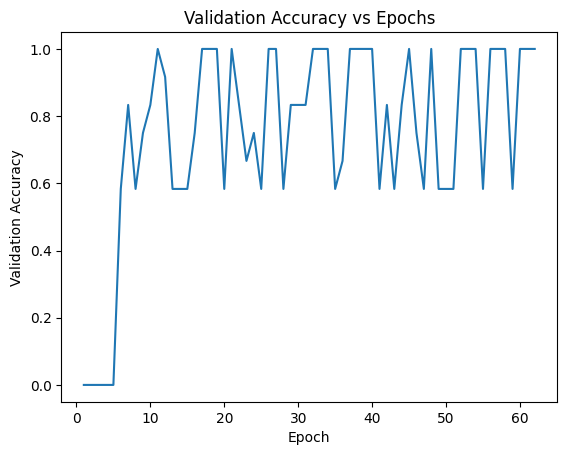


Metrics:


,Model,Train Accuracy,Test Accuracy,Num. Iters,Best Validation Score
0,1,0.666667,0.600000,62,1.000000
1,2,0.691667,0.566667,57,0.833333
2,3,0.891667,0.966667,114,1.000000
3,4,0.966667,0.900000,115,0.916667
4,5,0.958333,0.933333,121,0.916667



Averages:


,Metric,Average:
0,Train Accuracy:,0.835000
1,Test Accuracy:,0.793333
2,Num. Iters:,93.800000
3,Best Validation Score,0.933333


In [23]:
#Iris with early stopping and validation scores graph
# See problem above for EDA and splitting into X and y

train_accuracies = []
test_accuracies = []
n_iters = []
best_val_scores = []

# Do 5 random splits and train the model:
for i in range(5):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = 0.2
    )
    # train and fit the model
    mlp_classifier = MLPClassifier(
        hidden_layer_sizes = [64], 
        activation = "logistic",
        solver = "sgd",
        alpha = 0,
        batch_size = 1,
        learning_rate_init = 0.01,
        shuffle = True,
        momentum = 0,
        n_iter_no_change = 50,
        max_iter = 10000,
        early_stopping = True,
        validation_fraction = 0.1, #internally split the training set into a validation set, too
    )
    mlp_classifier.fit(X_train, y_train)

    # predicitions:
    train_pred = mlp_classifier.predict(X_train)
    test_pred = mlp_classifier.predict(X_test)

    # get accuracies and num iters:
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # num iters and best val scores
    iters = mlp_classifier.n_iter_
    best_val = mlp_classifier.best_validation_score_

    # add to lists / collect the metrics
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    n_iters.append(iters)
    best_val_scores.append(best_val)

    # for first run, plot the epochs vs accuracy on validation set
    if i == 0:
        # PLOT!!
        print("Validation Accuracy vs Epochs Graph for MLPClassifier 1:")
        plt.plot(range(1, len(mlp_classifier.validation_scores_)+1), mlp_classifier.validation_scores_)
        plt.xlabel("Epoch")
        plt.ylabel("Validation Accuracy")
        plt.title("Validation Accuracy vs Epochs")
        plt.show()

# turn into dictionaries, data frame, display
results = {"Model": [i for i in range(1, 6)], 
              "Train Accuracy": train_accuracies, 
              "Test Accuracy": test_accuracies, 
              "Num. Iters": n_iters,
              "Best Validation Score": best_val_scores}
results = pd.DataFrame(results)
print("\nMetrics:")
display(results)

# Get averages:
avg_train = sum(train_accuracies) / len(train_accuracies)
avg_test = sum(test_accuracies) / len(test_accuracies)
avg_iter = sum(n_iters) / len(n_iters)
avg_val_score = sum(best_val_scores) / len(best_val_scores)

# average dictionary, data frame, display:
averages = {"Metric": ["Train Accuracy:", "Test Accuracy:", "Num. Iters:", "Best Validation Score"], 
            "Average:" : [avg_train, avg_test, avg_iter, avg_val_score]}
averages = pd.DataFrame(averages)
print("\nAverages:")
display(averages)

#### Discussion
Report on the average number of iterations until convergence. What is the effect of the use of the validation set and early stopping on training set accuracy and testing set accuracy? What do you attribute the performance change to? What do you see in the validation scores graph?

I did the exact same thing as I did in the previous problem, just adding the coupled parameters in order to implement the early stopping with the validation set, and then adding a graph for one of the iterations to see how the accuracy changes with each of the epochs.

In this case, the train and test accuracy are actually worse than they were in the first one, with an average in the low 90s/high 80s for both the training and testing accuracies rather than being in the high 90s like it was before. This does not suprise me because, as was stated above, this data set is very simple. Early stopping, when the model already has limited data to train on, will make the model less accurate. Small data sets, by definiton, have a greater variance, and so this reduced accuracy is to be expected. All of this stuff in combination results in the reduced accuracy seen here. IT is also worth nothing that the number of iterations was cut, on average, in more than half, which makes sense as we are stopping the model early and so there will be less iterations that occur.

The graph is super variable, with super high highs and super sharp dips, sometimes when I run it I see straight lines and other interesting features, this is because there isn't a ton of data and the batch size is set so low, so at each epoch the accuracy can very drastically change resulting in the really shaky, sharp lines of the graph. This could be adjusted by increasing the batch size, or would naturally smooth out as a larger data set was used. 

Usually using a validation set and early stopping would not have this effect on a larger data set. Usually, it would decrease the training accuracy mildly, but would increase testing accuracy, meaning the model is better at generalizing.

### 1.3 (10%) Loss Regularization

- Do the same as in 1.1 but his time with loss regularization (Do not do early stopping)
- Run it with different L2 regularization parameter values (alpha).  The default for alpha is .0001.  Try other values such as .1, .01, .001, .00001, etc. Make a table with each row including:
    - The regularization parameter value
    - Number of iterations until convergence
    - Training set accuracy
    - Test set accuracy
    - Best loss value (MLPClassifer attribute best_loss_)
- Which regularization value gave you the best results?
- For your best regularization value do one run and create a graph with loss (*y*-axis) vs epochs (*x*-axis) for the training set (Hint: MLPClassifer attribute loss_curve_)


Averages:


,Alpha,Train Accuracy,Test Accuracy,Num Iterations,Best Loss
0,0.10000,0.482500,0.493333,48.5,1.655898
1,0.01000,0.848333,0.800000,106.5,0.890371
2,0.00100,0.973333,0.956667,151.0,0.293408
3,0.00010,0.965833,0.943333,144.1,0.215519
4,0.00001,0.974167,0.956667,150.9,0.193022



Loss vs Epochs graph:


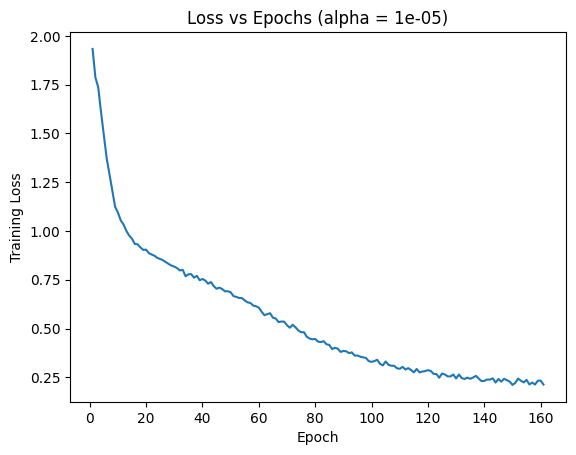

In [32]:
#Iris with Loss Regularization 
# See problem above for EDA and splitting into X and y

# Function for creating and fitting a mlp classifier
def mlp_func(alpha, X_train, y_train):
    """
    A function that initializes and fits an mlp classifier with a certain,
    predermined set of params, and a chosen alpha.

    Args:
        alpha (double): The alpha value to be used for the loss func
        X_train (np data frame): An data frame of all input features
        y_train (np series): A series of corresponding output features

    Returns:
        clf (MLPClassifier): A fitted MLP classifier
    """

    clf = MLPClassifier(
        hidden_layer_sizes = [64], 
        activation = "logistic",
        solver = "sgd",
        alpha = alpha, #get the alpha value
        batch_size = 1,
        learning_rate_init = 0.01,
        shuffle = True,
        momentum = 0,
        max_iter = 10000,
    )
    clf.fit(X_train, y_train)

    return clf

alphas = [0.1, 0.01, 0.001, 0.0001, .00001]

averages = []

# Do train the model 5 times for each of the alphas:
for alpha in alphas:
    train_accuracies = []
    test_accuracies = []
    n_iters = []
    best_losses = []
    for i in range(10):
        # train and fit the model
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size = 0.2, random_state = i)
        mlp_classifier = mlp_func(alpha, X_train, y_train)

        # predicitions:
        train_pred = mlp_classifier.predict(X_train)
        test_pred = mlp_classifier.predict(X_test)

        # get accuracies and num iters:
        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)

        # num iters and best val scores
        iters = mlp_classifier.n_iter_
        best_loss = mlp_classifier.best_loss_

        # add to lists / collect the metrics
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        n_iters.append(iters)
        best_losses.append(best_loss)

    # Get averages:
    avg_train = sum(train_accuracies) / len(train_accuracies)
    avg_test = sum(test_accuracies) / len(test_accuracies)
    avg_iter = sum(n_iters) / len(n_iters)
    avg_loss = sum(best_losses) / len(best_losses)

    # average dictionary, data frame, display:
    averages.append({
        "Alpha": alpha,
        "Train Accuracy": avg_train,
        "Test Accuracy": avg_test,
        "Num Iterations": avg_iter,
        "Best Loss": avg_loss
    })

# Display averages 
averages = pd.DataFrame(averages)
print("\nAverages:")
display(averages)

# Get the best alpha value and then train the 
best_row = averages.loc[averages["Best Loss"].idxmin()]
best_alpha = best_row["Alpha"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 0)
mlp_classifier = mlp_func(best_alpha, X_train, y_train)

# # PLOT THE BEST ONE!!!!!!!!!
print("\nLoss vs Epochs graph:")
plt.plot(range(1, len(mlp_classifier.loss_curve_)+1), mlp_classifier.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(f"Loss vs Epochs (alpha = {best_alpha})")
plt.show()

#### Discussion
Write about which regularization method gave you the best results and why you think that happened. Also compare: no regularization, early stopping, and L2 loss regularization.

Quick Process Overview:
    This one again, is quite similar to the two other parts of this problem. Here, because we are tuning hyperparameters, I decided to not only run the model for each of the alpha values, but to also run it for each of the alpha values several times. In this case, I chose to run it about 10 times each and find the average of each of them. I did a few additional things for this go around, including writing a function to train the classifier with the given alpha value because it seemed like a good way to decompose the problem. I also found the best alpha value by looking at the best loss category from the data frame that I made and found the index corresponding to the alpha value in which I did the graphing portion.

The alpha value that ended up being the best for me in this particular test was 0.00001, which actually had the exact same testing accuracy as 0.001, but it had a lower loss, so I ended up selecting it as the best one based on that rather than just the testing accuracy alone. The method that worked the best with this particular data set was actually no regularization - it had best tesing accuracy (though not by much compared to L2 loss). This could be because of a variety of reasons, one of which could be that the random split that I ran the first ones with just happened to be lucky and less of an accurate indicator of performance than the models in this sections, that were ran numerous times and all averaged together. A close second was L2 loss regularization, which had a testing accuracy that was just barely less than with no regularization. The one that came in last for test accuracy was early stopping, but, like we discussed before, this sharp drop in accuracy that is resulting from the fact that the data set is incredibly small and so the variance and lack of overall information rather greatly influences the average accuracy of models that use this method of regularization.

## 2 Hyperparameters 
In this section we use the [Vowel Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/vowel.arff) to consider the hyperparameters of learning rate, number of hidden nodes, and momentum. 

### 2.1 (10%) Vowel Dataset Questions
- Give the baseline accuracies for the Iris and Vowel datasets. Baseline accuracy is what you would get if the model just outputs the majority class of the data set (i.e. the output value which occurs most often). These two data sets are not great examples for this as they have an equal amount of each class, which is not typical.
- Discuss why the vowel data set will probably have lower accuracy than Iris.
- Consider which of the vowel dataset's input features you should not use in training and discuss why.

Baseline Accuracies:
    Given that the Iris data set has 150 instances, with three different classes, there will be 50 instances in each of the classes. So, it follows that:
        50/150 = 1/3 ~ 33.3% baseline accuracy if the model were to predict the "majority class" each time.
    Similarly, given that the Vowel data set has 990 instances and 11 different possible classes, there will be 90 instances of each of the classes. So, it follows that:
        90 / 990 = 1 / 11 ~ 9.1% baseline accuracy if the model were to predict the "majority class" each time.

Why will Vowel have data set have a lower accuracy than Iris?
    Just with intuiton, if in both data sets there is an even distribution of instances in each class, the data set with the larger number of classes will have a smaller proportion of instances in each of the classes (obviously!). So knowing this, if there is no majority class really, since they are all evenly distributed across the data set, the one that has the smaller number of output classes will have a higher proportion of instances in each of the classes and therefore have a higher baseline accuracy. This is supported by the math that is shown above. 

Which of Vowel's input features should not be used in training and discuss why?
    In general, things like ID numbers or any other kind of ordered data that is used for identification of an individual is left out of the training because those things are not actually influencing the output class. If these are included in the training of the model, it can throw the model off / cause it to memorize the training data based on data with no real effect / won't matter in the testing set, etc. So, in this case, it is likely that you would not use speaker number or the gender of the individual to train the model because these have little to no bearing on the results. Additionally, train and test here are unnecessary as we are going to use our own train and test splits, so these features can also be dropped / not used in training.

### 2.2 (10%) Learning Rate
Load the [Vowel Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/vowel.arff). Drop any features which you explained above as being inappropriate for training.

Hints: Consider the Pandas drop method for dropping columns. When you want to transform features in your data set there are lots of approaches. You could edit the arff file directly, or make the transforms in your code.  The Pandas replace method is nice for that. For example, if you wanted to change the vowel data set gender feature in a Pandas dataframe to 0/1 you could do the following:

vowel_df['Sex'] = vowel_df['Sex'].str.decode('utf-8')   //Changes the byte code data into a normal string, b'Male' becomes "Male"\
vowel_df = vowel_df.replace('Male', 0)\
vowel_df = vowel_df.replace('Female', 1)

- Use one layer of hidden nodes with the number of hidden nodes being twice the number of inputs.
- Use a random 75/25 split of the data for the training/test set.
- Do not use early stopping.
- Try at least 5 different learning rates (LR) from very small (e.g. .001) to pretty big (e.g. 10). Each LR will require a different number of epochs to learn. LR effects both accuracy and time required for learning.
- Create a table which includes a row for each LR.  Your table columns should be LR, # epochs to learn the model, final training set accuracy and final test set accuracy.  As learning rates get smaller, it usually takes more epochs to learn. If your model is stopping learning too soon (converging) by hitting max_iterations (in this case and in experiments below), then you need to increase your max_iterations parameter in order to give your model more learning time.  To keep things faster, you don't need to increase max_iter past 1000 if you don't want to, but point out when more iterations may have given improvement.

In real testing one averages the results of multiple trials per LR (and other parameters) with different intitial conditions (training/test split, initial weights, etc.). That gives more accurate results but is not required for this lab.

In [3]:
# Train with different learning rates
# Load arff

train_data, _ = arff.loadarff("data/vowel.arff")
vowel_df = pd.DataFrame(train_data)

# Quick EDA
print("Quick EDA of Vowels data set:")

print("\nFirst 5 rows of Vowel data set:")
display(vowel_df.head())

print("\nVowel Class Distributions: ")
display(vowel_df["Class"].value_counts().sort_index())

# X and y, drop columns said to be inapprporiate for training, decode/encode (?) classes
X = vowel_df.drop(["Train or Test", "Speaker Number", "Sex", "Class"], axis = 1)
vowel_df["Class"] = vowel_df["Class"].str.decode('utf-8')
le = LabelEncoder()
y = le.fit_transform(vowel_df["Class"])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state = 3
)

lr = [0.001, 0.01, 0.1, 1, 10]
train_accs = []
test_accs = []
epochs = []

for i in range(len(lr)):
    # Initialize and fit Classifier
    mlp_clf = MLPClassifier(
        hidden_layer_sizes = [22],
        max_iter = 5000,
        learning_rate_init = lr[i]
    )
    mlp_clf.fit(X_train, y_train)

    # Predict
    train_pred = mlp_clf.predict(X_train)
    test_pred = mlp_clf.predict(X_test)

    # Score
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # Epochs
    n_epochs = mlp_clf.n_iter_

    # Append
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    epochs.append(n_epochs)

# data frame, display
results = {
    "LR:": lr,
    "Num. Epochs": epochs,
    "Training Accuracy": train_accs,
    "Testing Accuracy:": test_accs
}
results = pd.DataFrame(results)
print("\nLearning rates of MLPClassifiers and their respective accuracies and n epochs:")
display(results)


Quick EDA of Vowels data set:

First 5 rows of Vowel data set:


,Train or Test,Speaker Number,Sex,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Class
0,b'Train',b'Andrew',b'Male',-3.639,0.418,-0.670,1.779,-0.168,1.627,-0.388,0.529,-0.874,-0.814,b'hid'
1,b'Train',b'Andrew',b'Male',-3.327,0.496,-0.694,1.365,-0.265,1.933,-0.363,0.510,-0.621,-0.488,b'hId'
2,b'Train',b'Andrew',b'Male',-2.120,0.894,-1.576,0.147,-0.707,1.559,-0.579,0.676,-0.809,-0.049,b'hEd'
3,b'Train',b'Andrew',b'Male',-2.287,1.809,-1.498,1.012,-1.053,1.060,-0.567,0.235,-0.091,-0.795,b'hAd'
4,b'Train',b'Andrew',b'Male',-2.598,1.938,-0.846,1.062,-1.633,0.764,0.394,-0.150,0.277,-0.396,b'hYd'



Vowel Class Distributions: 


Class
b'hAd'    90
b'hEd'    90
b'hId'    90
b'hOd'    90
b'hUd'    90
b'hYd'    90
b'had'    90
b'hed'    90
b'hid'    90
b'hod'    90
b'hud'    90
Name: count, dtype: int64


Learning rates of MLPClassifiers and their respective accuracies and n epochs:


,LR:,Num. Epochs,Training Accuracy,Testing Accuracy:
0,0.001,3247,0.998652,0.927419
1,0.010,636,1.000000,0.915323
2,0.100,150,0.977089,0.883065
3,1.000,33,0.095687,0.084677
4,10.000,37,0.102426,0.056452


#### Discussion
Discuss your table and the effect of different learning rates on both training time and accuracy

Discussion of Process:
    Here, again, just to detail my process and line of thought. I did the normal, loading the data set using loadarff, and then when I dropped the columns I detailed in the previous part as being ones that were "innapropriate" to use in the training set from my X. Additionally, for my y, before just defining it, I made sure to define a label encoder and then use that to decode the class labels from bytes to numbers to make sure that everything ran smoothly. Then, as per usual, I just used a simple loop to iterate through some preset values for this learning rate and added them to corresponding lists that could then be turned into tables. 

Additionally, I feel like it is worth noting that, different from problem one of this lab, I used the same split for each of the initialized and trained models to be better able to compare (and replicate) these results.

What I observed:
    For the larger values, I knew that since the model would be learning the data so quickly (I like to think about it like learning the data in big chunks, rather than slowly and meticulously) that the training and testing accuracies would be lower than normal, but I was shocked to see HOW much smaller that the accuracies were for 1 and 10 - both less than 10 percent! That is BY FAR the lowest accuracy I have seen, and makes a lot of sense in the context of them both only using 40ish epochs - compared to the several hundred that the smaller learning rates use. For the values that are less than 1, we see more typical values for training and testing accuracies. All of which have a training accuracy of between 0.98 and 1.00, and testing accuracies of between 0.88 and 0.91, so they are all pretty comprable to one another. Interestingly enough the training accuracy for the lr of 0.010 is 1.00, but it is less than that for 0.001. I ended up increasing the number of iterations allowed to allow a lr of 0.001 to go all the way through, it ended up with 2700 epochs, while 0.01 has 862 and 0.10 had just about 143, so there is definitely a rather obvious exponential growth there in the number of epochs as the lr decreases by a factor of 10 each time.

Because the training and testing accuracy of 0.01 are close enough together, I don't feel overly worried about the risk of overfitting. That in combination with the fact that it has the highest test accuracy, I feel like I can safely say that 0.01 is the best learning rate for this classifier.

### 2.3 (10%) Number of Hidden Nodes

Using the best LR you discovered, experiment with different numbers of hidden nodes.

- Start with 1 hidden node, then 2, and then double them for each test until you get no more improvement in accuracy. 
- Create a table just like above, except with # of hidden nodes rather than LR.

In general, whenever you are testing a parameter such as # of hidden nodes, keep testing values until no more improvement is found. For example, if 20 hidden nodes did better than 10, you would not stop at 20, but would try 40, etc., until you no longer got improvement.

In [55]:
# Train with different numbers of hidden nodes
# See above part for a quick EDA of the data 

# Split the data - use a 80/20 split for this one.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state = 3
)

hidden_nodes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
train_accs = []
test_accs = []
epochs = []

for i in range(len(hidden_nodes)):
    # Initialize and fit Classifier
    mlp_clf = MLPClassifier(
        hidden_layer_sizes = hidden_nodes[i],
        max_iter = 5000,
        learning_rate_init = 0.01,
        random_state = 3
    )
    mlp_clf.fit(X_train, y_train)

    # Predict
    train_pred = mlp_clf.predict(X_train)
    test_pred = mlp_clf.predict(X_test)

    # Score
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # Epochs
    n_epochs = mlp_clf.n_iter_

    # Append
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    epochs.append(n_epochs)

# data frame, display
results = {
    "Hidden Nodes": hidden_nodes,
    "Num. Epochs": epochs,
    "Training Accuracy": train_accs,
    "Testing Accuracy:": test_accs
}
results = pd.DataFrame(results)
print("\n Number of Hidden nodes of MLPClassifiers and their respective accuracies and n epochs:")
display(results)


 Number of Hidden nodes of MLPClassifiers and their respective accuracies and n epochs:


,Hidden Nodes,Num. Epochs,Training Accuracy,Testing Accuracy:
0,1,494,0.247978,0.213710
1,2,740,0.669811,0.616935
2,4,615,0.738544,0.737903
3,8,696,0.871968,0.717742
4,16,637,0.998652,0.866935
5,32,569,1.000000,0.927419
6,64,357,1.000000,0.931452
7,128,288,1.000000,0.951613
8,256,214,1.000000,0.951613
9,512,161,1.000000,0.955645


#### Discussion
Discuss your table and the effect of different numbers of hidden nodes on both training time and accuracy

Discussion of Process:
    Similar to above, I created empty lists that could be appended to for both accuracies and the number of epocs for each of the classifiers.

Contexts:
    It is important to note initially that the number of epochs (where an epoch is one full pass through the entire training dataset) is directly proportional to the time that it takes to train the model -> because more passes through the classifier means that it takes more time to train!

Discussion of Results:
    I tested hidden nodes 1-2048, where it doubles each time, in order to see the differences in accuracies as the model allows for more and more complex equations and patterns to be modeled. Networks that have very low hidden nodes (like 1-4) have pretty low training and testing accuracies and also relatively low number of epochs needed. Increasing the number of nodes has a general trend of increasing both training and testing accuracies, reaching 100% training accuracy after 32 nodes. Interestingly, the medium range of hidden nodes take a larger number of epochs to train (a longer time, too) than the ones with more nodes, this could be in part due to the fact that more nodes can capture more complex patterns (rather than skipping over it completely like the ones with less nodes) but they require more iterations to be able to do that. This could be why the models with more nodes are more (or at least comparably) accurate but can do so in a smaller amount of time. The testing accuracy seems to plateau at about a 0.95-0.96 testing accuracy. Between 128 and 1024 nodes there is very little flucctuation, so I would say that there is no significant improvement after 128 nodes, and the testing accuracy goes down for 2048 nodes. 

The general pattern here is that increasing the number of hidden nodes will improve training and testing accuracy until a certain point, after which they will offer little gain to improving accuracies. Training time seems to be highest for middle-sized networks, which is interesting, something that I didn't expect, but it definitely makes sense.


### 2.4 (10%) Momentum

Try at least 5 different momentum terms between 0 and just less than 1 using the best number of hidden nodes and LR from your earlier experiments.

- Create a table just like above, except with momentum values rather than LR or number of hidden nodes.

In [64]:
# Train with different momentum values
# See above part for a quick EDA of the data 

# Split the data - use a 80/20 split for this one.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state = 3
)

momentums = [0.1, 0.3, 0.5, 0.7, 0.9]
train_accs = []
test_accs = []
epochs = []

for i in range(len(momentums)):
    # Initialize and fit Classifier
    mlp_clf = MLPClassifier(
        hidden_layer_sizes = 128, # best number of hidden nodes
        max_iter = 5000,
        learning_rate_init = 0.01, # best lr
        solver = "sgd",
        momentum = momentums[i],
        random_state = 3
    )
    mlp_clf.fit(X_train, y_train)

    # Predict
    train_pred = mlp_clf.predict(X_train)
    test_pred = mlp_clf.predict(X_test)

    # Score
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # Epochs
    n_epochs = mlp_clf.n_iter_

    # Append
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    epochs.append(n_epochs)

# data frame, display
results = {
    "Momentum": momentums,
    "Num. Epochs": epochs,
    "Training Accuracy": train_accs,
    "Testing Accuracy:": test_accs
}
results = pd.DataFrame(results)
print("\nMomentum values of MLPClassifiers and their respective accuracies and n epochs:")
display(results)

c:\Users\User\Desktop\CS270\cs270_venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(



Momentum values of MLPClassifiers and their respective accuracies and n epochs:


,Momentum,Num. Epochs,Training Accuracy,Testing Accuracy:
0,0.1,5000,0.958221,0.870968
1,0.3,4666,0.973046,0.903226
2,0.5,4218,0.987871,0.923387
3,0.7,3457,0.997305,0.931452
4,0.9,1769,1.000000,0.947581


#### Discussion
Discuss your table and the effect of momentum on both training time and accuracy

Discussion of Process:
    It is the same coding process here, again, so I won't bore you with the minute details. But what is interesting and what I thought I would add to this section is that I was getting the same training and testing accuracies every time that I ran this for the momentum values, even when I changed the number of nodes and other things. I realized that I was using the wrong kind of solver for momentum to be able to work, and that fixed it right up!
Discussion of Results:
    Here, as the momentum is increased, the testing accuracy increases from about 0.87 to 0.94, and the training accuracy increases from 0.95 to 1.0 through the momentum values. What was interesting here to me is that the number of epochs for each of the models actually decrease as momentum increased. I didn't really know what to expect here, but it makes sense to me now. As I understand it, having a higher momentum value makes the model less senstive to little outliers or "bumps" in the gradients, it can remember more of the past information, unlike models with low momentum that can almost get bogged down by the current gradient and not be able to predict as well. As this related to epochs / training time, a model with a higher momentum can more easily move through the regions that don't have a lot of information, allowing them to converge more quickly / in fewer steps, compared to those models that focus too much on every minute detail (models with smaller momentum values). That is why we see here that the model with the highest accuracy (train and test) is also the model that trains the model most quickly.

I set the maximum epochs to 5000 here, I tried a few different things, slowly getting larger to allow the accuracies to improve. When max iter is set to something like 400 the accuracies are MUCH lower, which I thought was interesting and should be something to mention.

### 2.5 (10%) Automatic Hyperparameter Discovery
Using the vowel dataset, automatically adjust the LR, # of hidden nodes, and momentum using [grid and random search](https://scikit-learn.org/stable/modules/grid_search.html) 
- For grid search include the most promising hyperparameter values you used in your experiments above.  You may add others also.
- Be patient as the grid search can take a while since it has to train all combinations of models. Don't use too many parameter options or it will be too slow.
- Report your best hyperparameters and accuracy.  Unfortunately, you will not always get as high a score as you might expect.  This is in part due to the simplicity of the dataset.  It also teaches that in gerneral you should not blindly assume that a tool will get you the results you expect, and that you may need to consider multiple approaches.

In [6]:
#Grid search for hyperparameters.
#Here is one variation of code you could use for your grid search. You can try your own variation if you prefer.
# Quick EDA
print("Quick EDA of Vowels data set:")

print("\nFirst 5 rows of Vowel data set:")
display(vowel_df.head())

print("\nVowel Class Distributions: ")
display(vowel_df["Class"].value_counts().sort_index())

from sklearn.model_selection import GridSearchCV
clf = MLPClassifier(activation='logistic', solver='sgd',alpha=0,early_stopping=True, n_iter_no_change=10, batch_size=1)
parameters = {'learning_rate_init':(0.001, 1), #You have to fill in the rest of your values for these lists
              'hidden_layer_sizes': ([8], [32], [128]),
              'momentum':(0.3, 0.5, 0.9)}
grid = GridSearchCV(clf, parameters)
grid.fit(X, y)    #This takes a while to run
print(grid.best_params_)
print(grid.best_score_)

Quick EDA of Vowels data set:

First 5 rows of Vowel data set:


,Train or Test,Speaker Number,Sex,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Class
0,b'Train',b'Andrew',b'Male',-3.639,0.418,-0.670,1.779,-0.168,1.627,-0.388,0.529,-0.874,-0.814,hid
1,b'Train',b'Andrew',b'Male',-3.327,0.496,-0.694,1.365,-0.265,1.933,-0.363,0.510,-0.621,-0.488,hId
2,b'Train',b'Andrew',b'Male',-2.120,0.894,-1.576,0.147,-0.707,1.559,-0.579,0.676,-0.809,-0.049,hEd
3,b'Train',b'Andrew',b'Male',-2.287,1.809,-1.498,1.012,-1.053,1.060,-0.567,0.235,-0.091,-0.795,hAd
4,b'Train',b'Andrew',b'Male',-2.598,1.938,-0.846,1.062,-1.633,0.764,0.394,-0.150,0.277,-0.396,hYd



Vowel Class Distributions: 


Class
hAd    90
hEd    90
hId    90
hOd    90
hUd    90
hYd    90
had    90
hed    90
hid    90
hod    90
hud    90
Name: count, dtype: int64

{'hidden_layer_sizes': [8], 'learning_rate_init': 0.001, 'momentum': 0.9}
0.4878787878787879


In [4]:
#Randomized search for hyperparameters
#Here is one variation of code you could use for your randomized search.

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
clf = MLPClassifier(activation='logistic', solver='sgd',alpha=0,early_stopping=True, n_iter_no_change=10, batch_size=1)
distributions = dict(learning_rate_init=uniform(loc=0.001, scale=10), #loc is the min val, and loc + scale is the max val
                    hidden_layer_sizes = ([8], [128]), #since there is no distribution it samples these values uniformly
                    momentum=uniform(loc=0,scale =.99))
search = RandomizedSearchCV(clf, distributions, n_iter=10)
search.fit(X, y)
print(search.best_params_)
print(search.best_score_)

{'hidden_layer_sizes': [8], 'learning_rate_init': np.float64(1.6709006155159012), 'momentum': np.float64(0.2928294235851198)}
0.1616161616161616


#### Discussion
Write about and compare grid and randomized parameter search. How much time do they take? Which is more efficient or accurate? When should you use each?

Grid Search does a more systematic search of hyperparameters in order to tune them (to find the exact best option or combination of options)by doing all possible combinations of the hyperparameters that were provided in order to find the best of the provided values for each of the hyperparamter. This one is super nice when you have a small number of parameters, specific parameters you want to test, or want to find the best combination of these hyperparamters that you have. Grid Search can take a really long time though when you have a lot of parameters to test, the time it takes is exponential as the number of of hyperparamters increases. I don't know exactly what qualifies as a lot of hyperparameters to use with a gridsearch, but I used 4 different options for each of the hyperparameters that we were trying to determine and it was taking my compute over 30 minutes to figure out which params were good... so I cancelled that... and tried again with about 3 in each and it still took about 10 minutes to run.

On the other hand, a randomized search does a really good job of providing a kind of rough estimate / idea of what hyperparameters would work really well for the model. It can do this by randomly sampling from a distribution / range of values and returning accuracies from that. Because of the nature of this, it is really good for testing hyperparameters that exist on some sort of range or distribution (i.e. between 0 and 1 where there are infinitely many values) and spitting out a rough approximation of the optimal values. This one is much faster and less computationally expensive, it is way more optimal when you don't need exact params and have a LARGE data set. This one only took just over 2 minutes to run on my system.

As a whole, it seems like randomized searches are probably preferred and can be used really nicely to narrow down options, and then a grid search can be used to handle the specifics and the exact hyperparameters after it has been narrowed down a lot more. 

But, interestingly, both methods resulted in very different results for the best hyperparams. Because I am not that familiar with how these work internally, I would be interested to know why that is. I though there would at least be a little bit of consistency / similarity between them.

## 3 Regression with MLPs

### 3.1 (10%) - Learn a regression data set of your choice

Train MLP on any real world data set that requires regression (i.e. has a real valued ouput) and discuss your effort and results.  While the [Irvine ML Repository](https://archive.ics.uci.edu) is a great resource, also onsider [Kaggle](https://www.kaggle.com) and [OpenML](https://openml.org) as other great places to find datasets.
- Use [MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html#sklearn.neural_network.MLPRegressor) rather than MLPclassifier.  It has almost the exact same setup as MLPClassier except it uses the linear activation function for the output nodes and SSE as the loss function.  MLPClassier uses softmax activation for the output nodes and cross-entropy for the loss function.
- Use any reasonable hyperparameters that you want.  
- You will probably need to normalize input features.
- It is not typically necessary to normalize the output.
- Split into train and test and report the training and test set MAEs (Mean Absolute Error). For regression problems where we don't normalize the output, MAE is an intuitive measure as it shows exactly how much our output is off on average.

In [21]:
# Load and Learn a real world regression data set
# To calculate MAE you could do a variation of the following

# Load the data
wine_df = pd.read_csv("data/winequality-red.csv", sep=';')

# Quick EDA
print("Quick EDA:")
print("\nFirst 5 rows of the Air Quality dataset:")
display(wine_df.head())

print("\nWine Quality Distribution:")
display(wine_df["quality"].value_counts().sort_index())

# X and y
X = wine_df.drop(["quality"], axis = 1)
y = wine_df["quality"]

# Split into train and test using an 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 123
)

# Scale / standardize the X train values and X test values separately 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit a basic MLPRegressor (make an estimate of hyperparams to get a good **baseline** to compare to!)
mlp_reg_base = MLPRegressor(
    hidden_layer_sizes = [32],
    solver = "sgd",
    momentum = 0.9,
    n_iter_no_change = 25
)
mlp_reg_base.fit(X_train_scaled, y_train)


from sklearn.metrics import mean_absolute_error
print("Baseline mean_absolute error:")
print(mean_absolute_error(mlp_reg_base.predict(X_test_scaled), y_test))

Quick EDA:

First 5 rows of the Air Quality dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Wine Quality Distribution:


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Baseline mean_absolute error:
0.5186511650862307


c:\Users\User\Desktop\CS270\cs270_venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


#### Discussion
Report on your choice of data set and your results. How does the MLPRegressor differ from the MLPClassifier? What are their respective uses? What lessons from above did you use?

Here, I chose a red wine quality data set that had just under 2000 instances, all numeric features, and no missing values. I largely did this to make it an easier process to clean / arrange the data in order to run this regression and get a baseline MAE from the model.

For starters, obviously the MLPRegressor is used to run a regression (predict continuous values) while the MLPClassifier is used to run a classification (predict class labels (discrete)). Both of them will use the same underlying neural network set up, but are both configured slightly differently for their respective tasks. Like mentioned above, a MLPRegressor uses the linear activation function for the output nodes and SSE as the loss function, rather than softmax activation and cross-entropy loss, like the MLPClassifier does. Both of them are configured in a way that will allow them to perform better at their specific task!

Based on all the things that we did above, I decided that a slightly larger than middle-ground average sized of hidden nodes in order to get a good accuracy/small error while still having a smaller training time would perform the best here. In addition to that, I thought it was really interesting how much better the model would perform when using the stochastic gradient descent solver and a slightly larger momentum values (this is because the model doesn't care too much / or get too distracted over the small inconsistencies, and is better able to observe the overall patterns, and therefore generalize to the test data). Really the last thing that I did that I learned from the lessons above is to mess around with and include the limitation on the number of iterations that can occur with no change happening. Here, I ended up going with 25 which resulted in just a slightly lower MAE, but was interesting to see how it affected the MAE.

Overall, I got a MAE of around 0.5, which is honestly not that bad considering I really didn't tune anything, other than a little manual experimentation with the n_iter_no_change part of the regressor.

### 3.2 (10%) - Other MLP Hyperparameters 
With the same data set, you may (not required) experiment with some of the hyperparameters you already did above (LR, hidden nodes, momentum, validation set parameters, regularization).  But for sure experiment with and discuss the results of the first two hyperparameters below (activation functions and multiple hidden layers).  We encourage you to experiment briefly with the others but they are not required. 

- different hidden layer activation functions (tanh, relu in addition to logistic) - Note that Sklearn does not currently let you choose the output layer activation function.  It is automatically softmax for classification and linear for regression.
- more than one hidden layer
- solver - try adam and lbfgs in addition to sgd
- batch size
- learning rate adaptation - this is the schedule parameter which lets LR adapt during learning

In [25]:
# Run with different hyperparameters
# Experiment with hyperparams.

# See above problem for an EDA of this data set.

from sklearn.metrics import r2_score

activations = ["logistic", "tanh", "relu"]
layers = [
    (32,),
    (64,),
    (32, 16),
    (64, 32),
]

results = []

for act in activations:
    for layer in layers:
        model = MLPRegressor(
            activation=act,
            hidden_layer_sizes=layer,
            solver="adam",
            max_iter=1000,
            random_state=42
        )
        
        model.fit(X_train_scaled, y_train)

        # Predict
        preds = model.predict(X_test_scaled)

        # Metrics
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        
        # Append
        results.append({
            "Activation": act,
            "Layers": layer,
            "MAE": mae,
            "Test R2": r2
        })

# display results
results = pd.DataFrame(results)
print("MAE for various layer/node and acitvation function combinations:")
display(results)

c:\Users\User\Desktop\CS270\cs270_venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MAE for various layer/node and acitvation function combinations:


,Activation,Layers,MAE,Test R2
0,logistic,"(32,)",0.530699,0.348171
1,logistic,"(64,)",0.531998,0.345438
2,logistic,"(32, 16)",0.537173,0.297319
3,logistic,"(64, 32)",0.491650,0.419749
4,tanh,"(32,)",0.499403,0.389732
5,tanh,"(64,)",0.490093,0.414392
6,tanh,"(32, 16)",0.509879,0.321369
7,tanh,"(64, 32)",0.497718,0.366056
8,relu,"(32,)",0.523588,0.340485
9,relu,"(64,)",0.528297,0.310560


#### Discussion
How do the hyperparameters affect your accuracy? Specifically the number of layers and nodes and activation functions you experimented with. Do the solver, batch size, and learning rate adaptation affect anything?


Discussion of Process:
    The same drill. I tried to use the built in hyperparameter tuners, but they take a long time and I like to be able to easily display the results of each of the runs that I did. So, I stuck to what I am comfortable with, and went ahead and just chose some reasonable values to iterate through in a for loop and be able to see the results of each at the end. Nothing special!

Discussion of Results:
    A displayed a table with the MAW and the R2 score for each of the combinations that I tried. Keeping in mind that the baseline regression model that I trained had an MAE of about 0.52, let's get into it. In terms of activation functions, the logistic function had a range of about 0.49 to 0.53 for the MAE and a R2 of 0.29 ro 0.42, which suggets that it can perform well (it had the highest R2) but that it is rather variable in it's results. For Tanh, it seems to be slightly more stable (MAE: 0.49-0.51 and R2 0.32-0.41) than the logistic, still a little variable, but seems to have a better balance between the two metrics. Lastly, for ReLU (MAE: 0.50-0.53 and R2 0.28-0.35), it has both a worse MAW and R2, suggesting that it probably is not the choice for this particular data set. Briefly, in terms of layers and nodes, when the network is small and deep, it has a worse performance than when it is wide / large and deep, actoss the board, for both metrics. The layers/nodes that had the best performance was (64, 32) which was the biggest one I tested, suggesting that more computing power was needed to better capture these patterns.

Really, the large variability in the answers for each of these combinations signals to me that there are either better hyperparams that could have been use, that there wasn't enough data to properly get generalizable results, or that my model wasn't fully converging, or a combination of all of them. In real life if I were training this, there would be a lot more to do to get it in a good shape.

I opted not to experiment with the other hyperparameter tuning for this part, so I do not have concrete data to back up what I am about to say, but I do have some intuition about how some of these could change the MAE. I know that different solvers have different levels of stability / are more or less sensitive to noise and messy data, so some of the solvers could have more variable results and a higher MAE. I chose adam here because, as I understand it, it is one of the more stable ones. Batch size determines the number of samples that are used per update, having a batch size that is too small can make the updates incredibly noisy and variable and random, while having a batch size that is much too large will be faster and have a smoother training experience, but can miss optimal solutions and patterns. I just used the auto / default for this. The last one that was mentioned in the prompt for this question was the learning rate adaptation which is just a control for how the learning rate changes as the model is training. Adaptive learning rates seem to be one of the better becuase they reduce the learning rate as the model goes, allowing it to gain some baseline information at the beginning and then fine tune it's ideas as it goes. All of these would be great things to see, if I had the time!

## 4. (Optional 20% extra credit) Code up your own MLP/Backprop learner 
Below is a scaffold you could use if you want. Requirements for this task:
- Your model should support the methods shown in the example scaffold below.
- Ability to create a network structure with at least one hidden layer and an arbitrary number of nodes. You may choose just one non-linear activation function for all hidden and output nodes if you want (e.g. sigmoid activation function where the loss is SSE rather than cross-entropy).
- Random weight initialization with small random weights with 0 mean. Remember that every hidden and output node should have its own bias weight.
- Use stochastic training updates: update weights after each training instance (i.e. not batch)
- Option to include a momentum term
- Your class can inherit from the relevant scikit-learn learners (e.g. data shuffling, etc.), but don't call any of the super methods to accomplish the core methods in the scaffold.
- Run the Iris data set above with your Backprop version. Show and discuss your results and how they compare with the sklearn version.
- Coding MLP is a good experience but is a little more challening than implementing other models so the extra credit points are higher than typical.

*Discuss your results and any differences*

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

class MLP(BaseEstimator,ClassifierMixin):

    def __init__(self,lr=.1, momentum=0, shuffle=True,hidden_layer_widths=None):
        """ Initialize class with chosen hyperparameters.

        Args:
            lr (float): A learning rate / step size.
            shuffle(boolean): Whether to shuffle the training data each epoch. DO NOT SHUFFLE for evaluation / debug datasets.
            momentum(float): The momentum coefficent 
        Optional Args (Args we think will make your life easier):
            hidden_layer_widths (list(int)): A list of integers which defines the width of each hidden layer if hidden layer is none do twice as many hidden nodes as input nodes. (and then one more for the bias node)
            For example: input width 1, then hidden layer will be 3 nodes
        Example:
            mlp = MLP(lr=.2,momentum=.5,shuffle=False,hidden_layer_widths = [3,3]),  <--- this will create a model with two hidden layers, both 3 nodes wide
        """
        self.hidden_layer_widths
        self.lr = lr
        self.momentum = momentum
        self.shuffle = shuffle


    def fit(self, X, y, initial_weights=None):
        """ Fit the data; run the algorithm and adjust the weights to find a good solution

        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
            y (array-like): A 2D numpy array with the training targets
        Optional Args (Args we think will make your life easier):
            initial_weights (array-like): allows the user to provide initial weights
        Returns:
            self: this allows this to be chained, e.g. model.fit(X,y).predict(X_test)

        """
        self.weights = self.initialize_weights() if not initial_weights else initial_weights

        return self

    def predict(self, X):
        """ Predict all classes for a dataset X
        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
        Returns:
            array, shape (n_samples,)
                Predicted target values per element in X.
        """
        pass

    def initialize_weights(self):
        """ Initialize weights for perceptron. Don't forget the bias!

        Returns:

        """

        return [0]

    def score(self, X, y):
        """ Return accuracy of model on a given dataset. Must implement own score function.

        Args:
            X (array-like): A 2D numpy array with data, excluding targets
            y (array-like): A 2D numpy array with targets

        Returns:
            score : float
                Mean accuracy of self.predict(X) wrt. y.
        """

        return 0

    ###  Returns the weights. Not required but helpful for debugging
    def get_weights(self):
        pass
